In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('../data/train.csv', parse_dates=['Date'])
stores = pd.read_csv('../data/stores.csv')

print(train.shape)
print(train['Date'].min(), '→', train['Date'].max())
print(train['Store'].nunique(), 'stores,', train['Dept'].nunique(), 'departments')

(421570, 5)
2010-02-05 00:00:00 → 2012-10-26 00:00:00
45 stores, 81 departments


In [2]:
store_weekly = (train
                .groupby(['Store', 'Date'], as_index=False)['Weekly_Sales']
                .sum())

print(store_weekly.shape)
print(store_weekly.head())

(6435, 3)
   Store       Date  Weekly_Sales
0      1 2010-02-05    1643690.90
1      1 2010-02-12    1641957.44
2      1 2010-02-19    1611968.17
3      1 2010-02-26    1409727.59
4      1 2010-03-05    1554806.68


In [3]:
store_weekly = store_weekly.merge(stores[['Store', 'Type']], on='Store')

type_weekly = (store_weekly
               .groupby(['Type', 'Date'], as_index=False)['Weekly_Sales']
               .sum())

total_weekly = (store_weekly
                .groupby('Date', as_index=False)['Weekly_Sales']
                .sum())

print(type_weekly.shape, total_weekly.shape)
print(stores['Type'].value_counts())

(429, 3) (143, 2)
Type
A    22
B    17
C     6
Name: count, dtype: int64


In [4]:
check = total_weekly.merge(
    type_weekly.groupby('Date', as_index=False)['Weekly_Sales'].sum(),
    on='Date', suffixes=('_total', '_from_types'))

check['diff'] = check['Weekly_Sales_total'] - check['Weekly_Sales_from_types']
print(check['diff'].abs().max())

7.450580596923828e-09


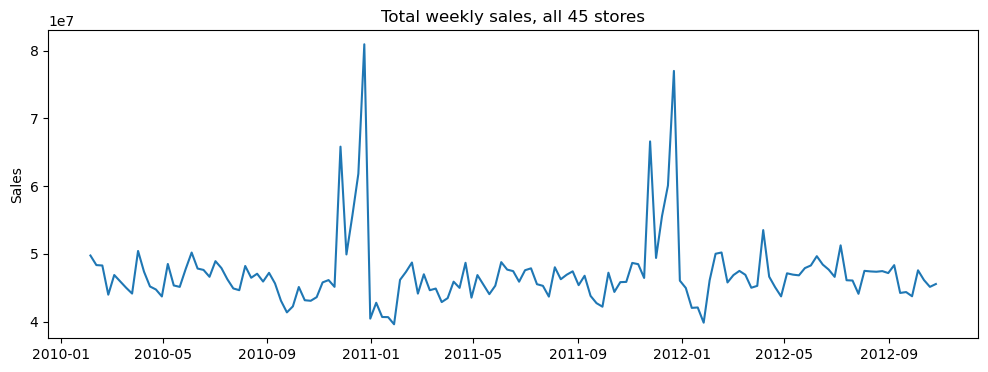

In [5]:
plt.figure(figsize=(12,4))
plt.plot(total_weekly['Date'], total_weekly['Weekly_Sales'])
plt.title('Total weekly sales, all 45 stores')
plt.ylabel('Sales')
plt.show()

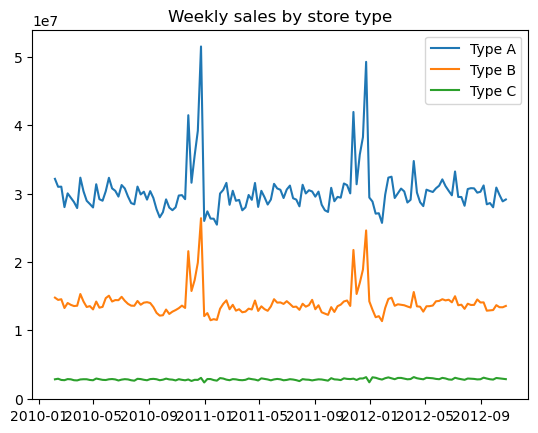

In [6]:
for t in ['A','B','C']:
    sub = type_weekly[type_weekly['Type']==t]
    plt.plot(sub['Date'], sub['Weekly_Sales'], label=f'Type {t}')
plt.legend()
plt.title('Weekly sales by store type')
plt.show()

143 weeks, 45 stores, no missing weeks. Hierarchy built as Total → Type (3) → Store (45); levels sum exactly (max discrepancy 7.5e-09).

Baseline is flat with no growth trend; the dominant feature is an annual Christmas spike preceded by a sharp dead week. Types A and B show the spike, Type C does not — different seasonal profiles justify the type level rather than modelling total sales alone.